In [1]:
import sys
print(sys.executable)

C:\Users\dorian\AppData\Local\pypoetry\Cache\virtualenvs\itpt-lW0Igsa9-py3.13\Scripts\python.exe


In [1]:
import matplotlib.pyplot as plt
import cv2
import easyocr

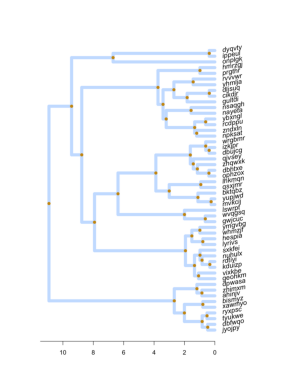

In [3]:
img_path = "dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_6.png"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [14]:
reader = easyocr.Reader(["en"], gpu=False)
results = reader.readtext(image, rotation_info=[10, 20, 30, 40, 50, 60, 70, -10, -20, -30, -40, -50, -60, -70], text_threshold=0.2, low_text=0.5)

print(f"Nombre de textes détectés : {len(results)}")

Using CPU. Note: This module is much faster with a GPU.


Nombre de textes détectés : 51


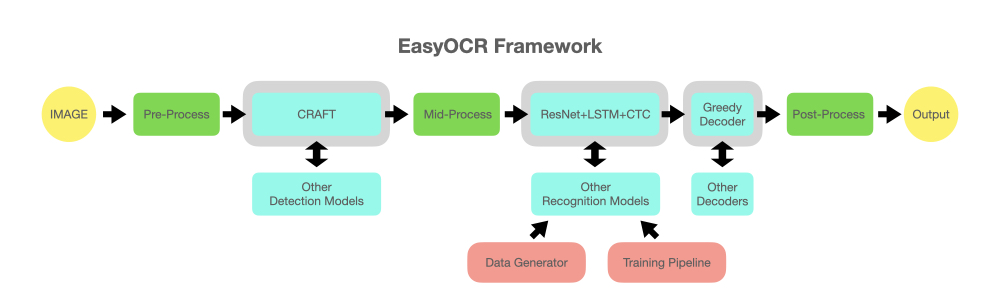

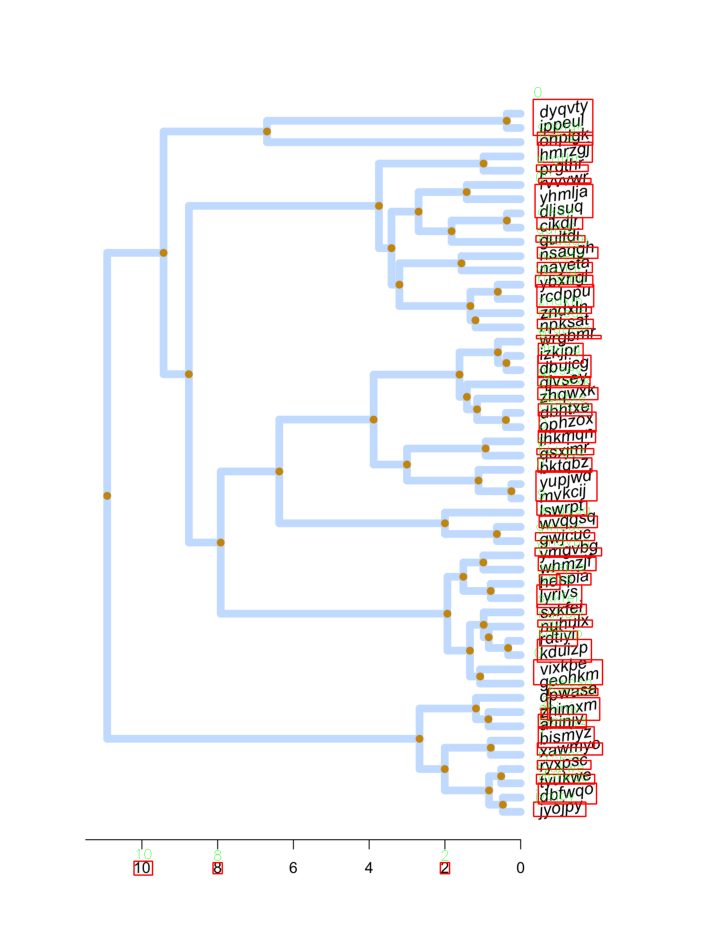

In [15]:
plt.figure(figsize=(12,12))
img_show = image.copy()
for bbox, text, score in results:
    x1, y1 = bbox[0]
    x2, y2 = bbox[2]
    cv2.rectangle(img_show, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 2)
    cv2.putText(img_show, text, (int(x1), int(y1)-5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 1)
plt.imshow(img_show)
plt.axis('off')
plt.show()

In [7]:
filtered_text_boxes = [
    {"bbox": bbox, "text": text, "score": score}
    for bbox, text, score in results
    if not any(char.isdigit() for char in text)
]

for i, entry in enumerate(filtered_text_boxes[:20], 1):
    print(f"{i}: text='{entry['text']}', score={entry['score']:.2f}, bbox={entry['bbox']}")

1: text='kltpib', score=1.00, bbox=[[np.int32(1175), np.int32(202)], [np.int32(1258), np.int32(202)], [np.int32(1258), np.int32(241)], [np.int32(1175), np.int32(241)]]
2: text='xthslq', score=1.00, bbox=[[np.int32(1177), np.int32(235)], [np.int32(1265), np.int32(235)], [np.int32(1265), np.int32(271)], [np.int32(1177), np.int32(271)]]
3: text='ftSXcv', score=0.49, bbox=[[np.int32(1176), np.int32(272)], [np.int32(1264), np.int32(272)], [np.int32(1264), np.int32(302)], [np.int32(1176), np.int32(302)]]
4: text='Iwotrm', score=0.98, bbox=[[np.int32(1178), np.int32(300)], [np.int32(1274), np.int32(300)], [np.int32(1274), np.int32(332)], [np.int32(1178), np.int32(332)]]
5: text='emvljn', score=1.00, bbox=[[np.int32(1179), np.int32(327)], [np.int32(1273), np.int32(327)], [np.int32(1273), np.int32(363)], [np.int32(1179), np.int32(363)]]
6: text='gyqbyz', score=0.99, bbox=[[np.int32(1173), np.int32(354)], [np.int32(1284), np.int32(354)], [np.int32(1284), np.int32(402)], [np.int32(1173), np.int32